# Strategic Audit of the PCV Program in Guatemala
### Second Notebook: Data Preparation, Structural Validation, and Exploratory Data Analysis

This notebook builds on the analytical framework developed in the first stage by consolidating fragmented program information into a structured analytical dataset. The objective is to integrate heterogeneous sources into a coherent project-level structure and verify the internal consistency of the reconstructed variables before moving toward deeper analysis.

Given the proxy-based and reconstructed nature of the dataset, the purpose of this notebook is not statistical inference, but rather data consolidation, structural validation, and analytical preparation. The analysis focuses on validating relationships across organizational levels (deliverables, projects, mandates, and partners) and assessing the coherence of the constructed indicators.

The notebook combines data integration, exploratory data analysis (EDA), and cross-level consistency checks to validate the reconstructed program architecture and prepare the dataset for subsequent interpretative and exploratory analytical work.

**Author:** J-F Jutras  
**Date:** May 2026  
**Dataset:** SUCO PCV Program Data (Guatemala)

## 2.1-Data Loading and Overview

In [1]:
import pandas as pd
import warnings

# Suppress openpyxl warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Define base path for dataset
base_path = "/kaggle/input/datasets/jfjutras07/pcv-guatemala-dataset/"

# Load all tables
df_capacidades = pd.read_excel(base_path + "Tabla_capacidades.xlsx")
df_componentes = pd.read_excel(base_path + "Tabla_componentes.xlsx")
df_cooperantes = pd.read_excel(base_path + "Tabla_cooperantes.xlsx")
df_entregables = pd.read_excel(base_path + "Tabla_entregables.xlsx")
df_mandatos = pd.read_excel(base_path + "Tabla_mandatos.xlsx")
df_proyectos = pd.read_excel(base_path + "Tabla_proyectos.xlsx")
df_socios = pd.read_excel(base_path + "Tabla_socios.xlsx")

# Clone utility repository
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
import sys
sys.path.append("/kaggle/working/jfj-utils")

# Quick check
for name, df in list(globals().items()):
    if name.startswith("df_") and isinstance(df, pd.DataFrame):
        print("\n" + "="*50)
        print(f"Dataset: {name}")
        print("="*50)
        df.info()

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (280/280), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 3527 (delta 224), reused 96 (delta 96), pack-reused 3247 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 9.38 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.

Dataset: df_capacidades
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_capacitad         7 non-null      int64 
 1   familia_capacidades  7 non-null      object
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes

Dataset: df_componentes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID_componente      42 non-null     int64 


**Data Quality Profiling**

In [2]:
# Define dataset dictionary for iterative EDA
tables = {
    "capacidades": df_capacidades,
    "componentes": df_componentes,
    "cooperantes": df_cooperantes,
    "entregables": df_entregables,
    "mandatos": df_mandatos,
    "proyectos": df_proyectos,
    "socios": df_socios
}

# Initialize summary container
eda_summary = []

# Compute structural metrics for each table
for name, df in tables.items():
    
    eda_summary.append({
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_rate": df.isna().mean().mean(),
        "duplicate_rows": df.duplicated().sum()
    })

# Convert results into a structured DataFrame
summary_df = pd.DataFrame(eda_summary)

# Display structural summary
print(summary_df)

         table  rows  cols  missing_rate  duplicate_rows
0  capacidades     7     2      0.000000               0
1  componentes    42     3      0.000000               0
2  cooperantes    10     7      0.000000               0
3  entregables   124    11      0.000000               0
4     mandatos    11     9      0.000000               0
5    proyectos    32    32      0.175781               0
6       socios     6     4      0.000000               0


The dataset exhibits structurally clean relational design with no duplicated records across tables. Missing values are concentrated in project-level and organizational attributes, and are consistent with heterogeneous program measurement practices rather than data quality issues. This suggests structured missingness driven by contextual applicability and evaluation design rather than random data loss.

**Data Model Consistency Overview**

In [3]:
# Standardize column names (lowercase + strip spaces)
for name in tables:
    tables[name].columns = tables[name].columns.str.strip().str.lower()

# Define relational structure between program levels
relations = [
    ("componentes", "id_capacidad", "capacidades", "id_capacitad"),
    ("mandatos", "id_capacidad", "capacidades", "id_capacitad"),
    ("mandatos", "id_cooperante", "cooperantes", "id_cooperante"),
    ("entregables", "id_proyecto", "proyectos", "id_proyecto"),
    ("entregables", "id_socio", "socios", "id_socio"),
    ("entregables", "id_mandato", "mandatos", "id_mandato"),
    ("proyectos", "id_componente", "componentes", "id_componente")
]

# Store referential integrity results
validation_results = []

# Compute orphan rates for each relationship
for child, child_key, parent, parent_key in relations:
    
    child_keys = set(tables[child][child_key].dropna())
    parent_keys = set(tables[parent][parent_key].dropna())
    
    orphan_keys = child_keys - parent_keys
    
    validation_results.append({
        "relationship": f"{child} -> {parent}",
        "orphan_count": len(orphan_keys),
        "orphan_rate": len(orphan_keys) / len(child_keys) if len(child_keys) > 0 else 0
    })

# Convert to DataFrame
validation_df = pd.DataFrame(validation_results)

# Display summary
print(validation_df)

                 relationship  orphan_count  orphan_rate
0  componentes -> capacidades             0          0.0
1     mandatos -> capacidades             0          0.0
2     mandatos -> cooperantes             0          0.0
3    entregables -> proyectos             0          0.0
4       entregables -> socios             0          0.0
5     entregables -> mandatos             0          0.0
6    proyectos -> componentes             0          0.0


The relational structure shows perfect referential integrity across all program levels, with no orphan records detected in any relationship. This confirms full consistency of the reconstructed data model and validates the coherence of the hierarchical program structure.

## 2.2-EDA of Proxy Indicators

This section explores the distributional properties of the constructed proxy indicators used to operationalize program dimensions such as complexity, quality, adoption, outcomes, contextual, and risk conditions. The objective is to assess the variability, dispersion, and overall discriminative capacity of the scoring system, in order to validate its suitability for downstream analytical use.

**Deliverable-Level Proxy Distribution**

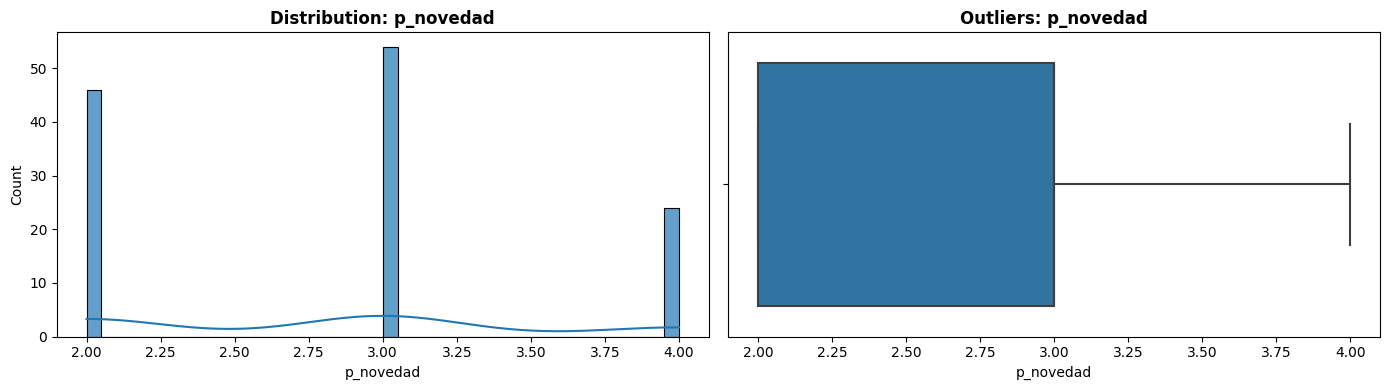

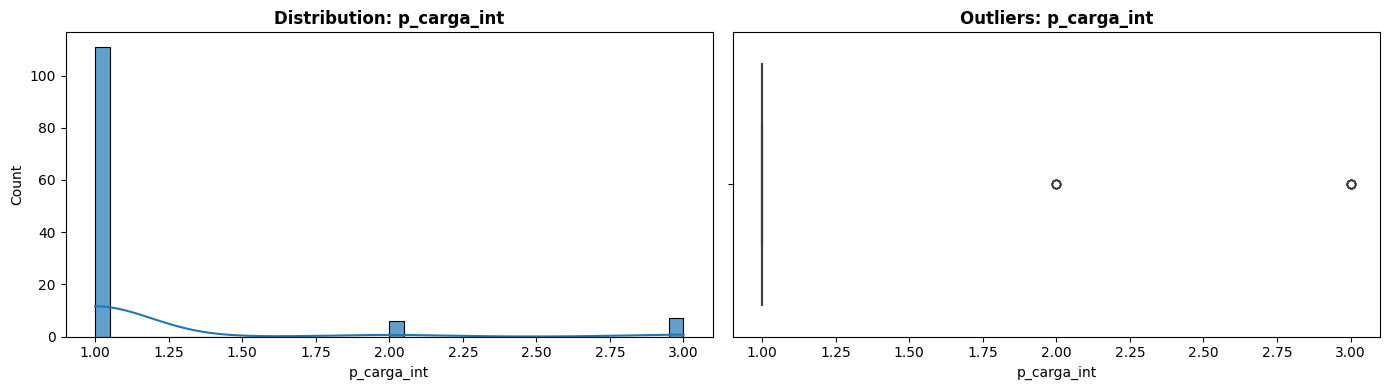

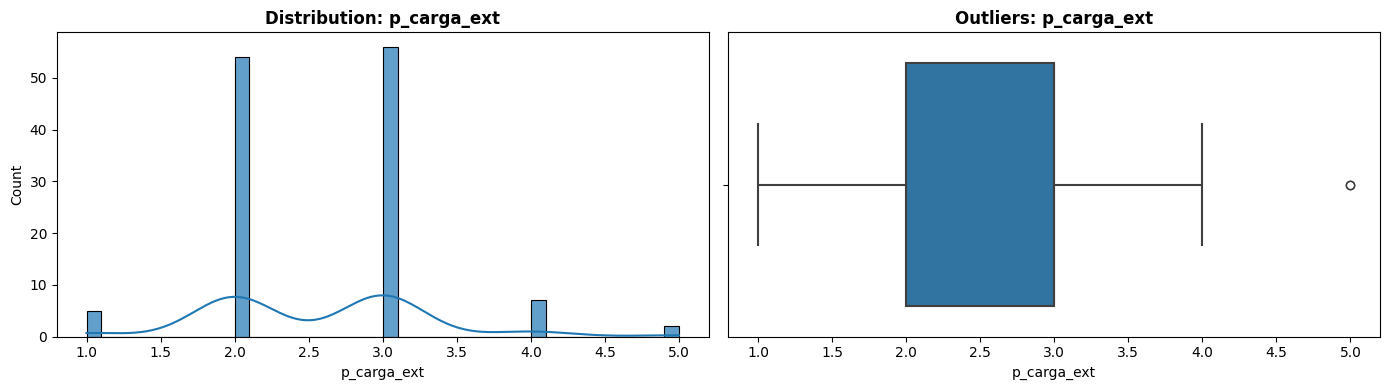

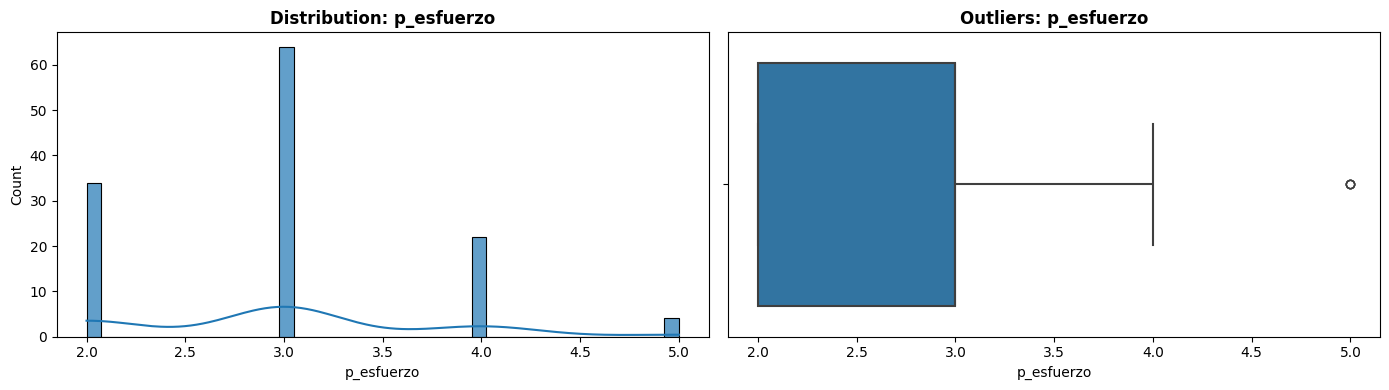

In [4]:
#Define columns
entregables_cols = ['p_novedad', 'p_carga_int', 'p_carga_ext', 'p_esfuerzo']

from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df_entregables, entregables_cols)

The distributions show marked heterogeneity across variables, with *p_carga_int* highly concentrated at the lowest level, reflecting a consistently low level of internal team size per sub-deliverable (typically one internal person). In contrast, *p_carga_ext* and *p_esfuerzo* display broader dispersion, suggesting variability in external involvement and overall effort intensity. 

Overall, *p_novedad* and *p_esfuerzo* are centered around mid-range values, while *p_carga_int* exhibits very limited variability, indicating a structurally consistent pattern of low internal staffing per deliverable, which may reflect a decentralized or individually anchored execution model rather than multi-actor internal coordination.

**Project-Level Proxy Distribution**

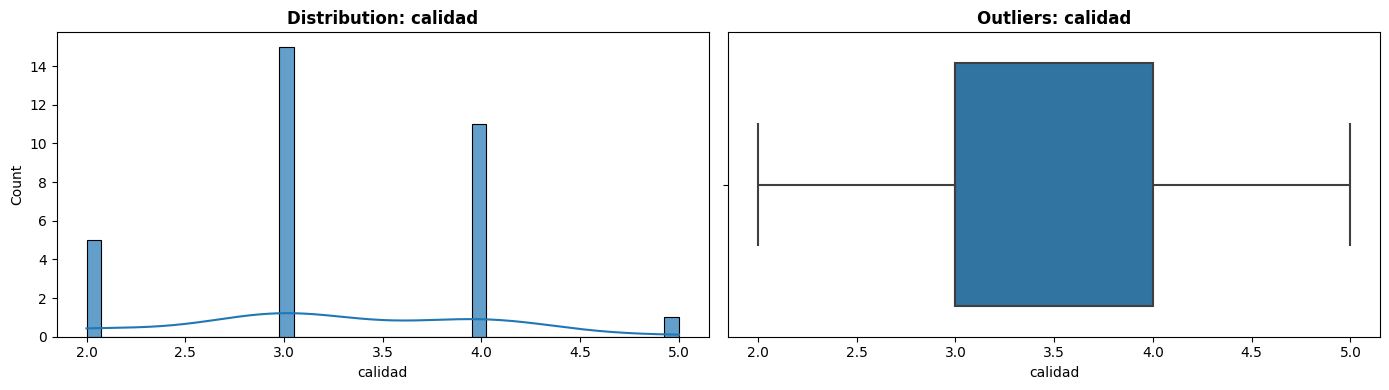

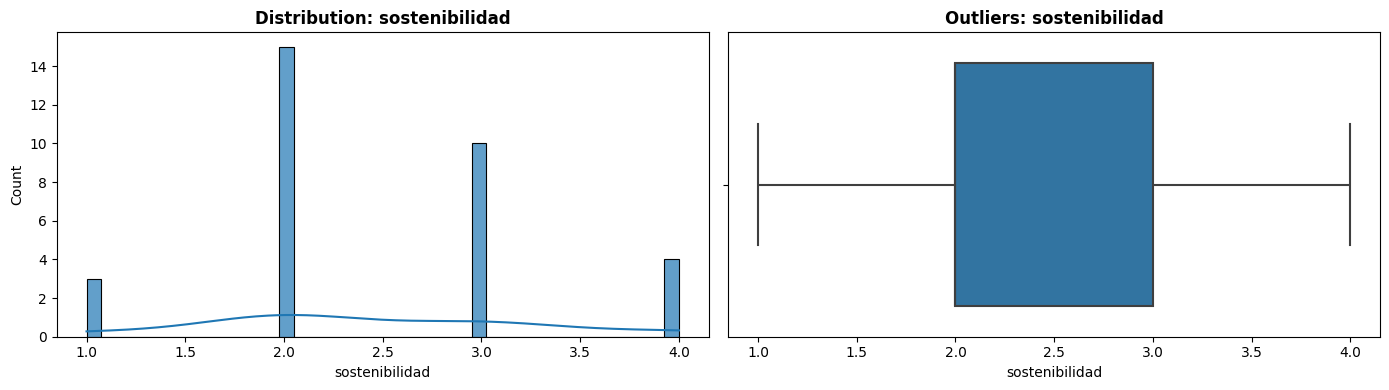

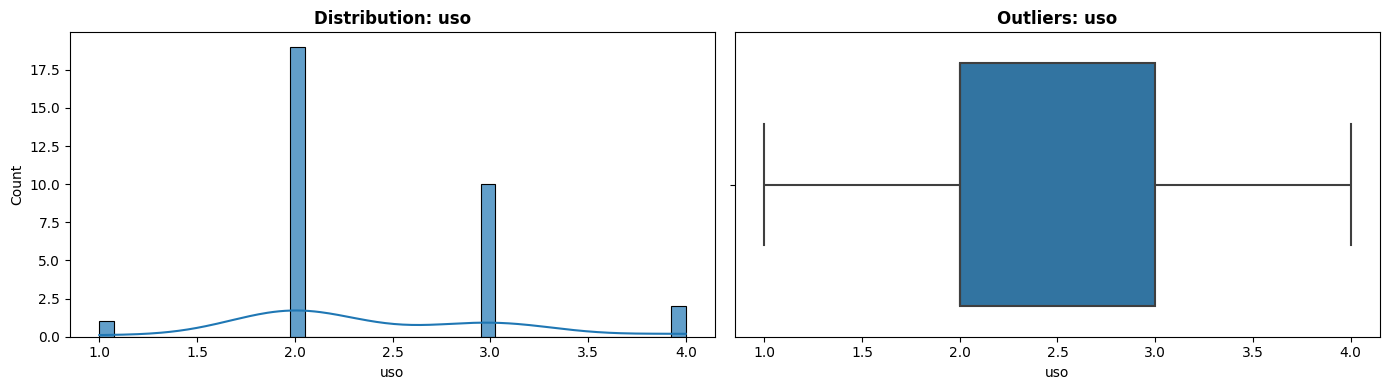

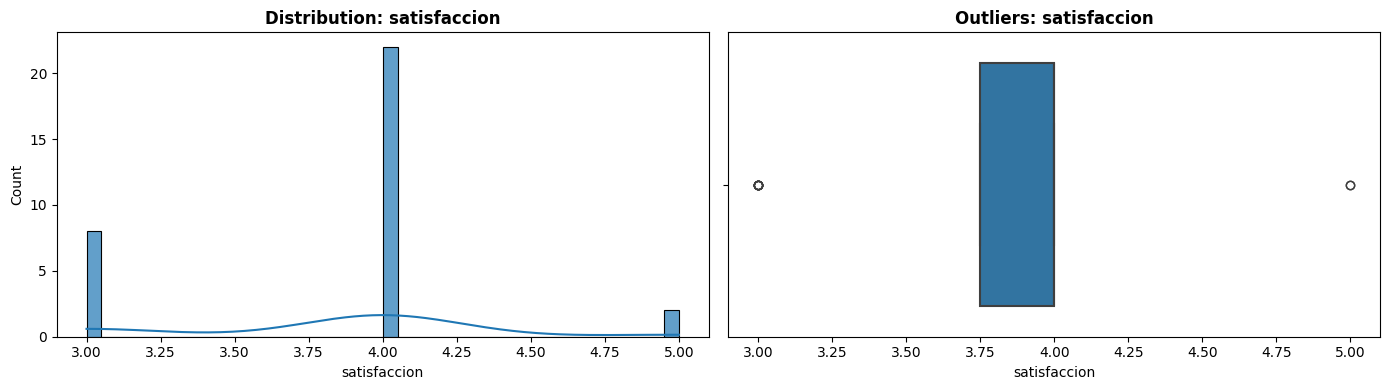

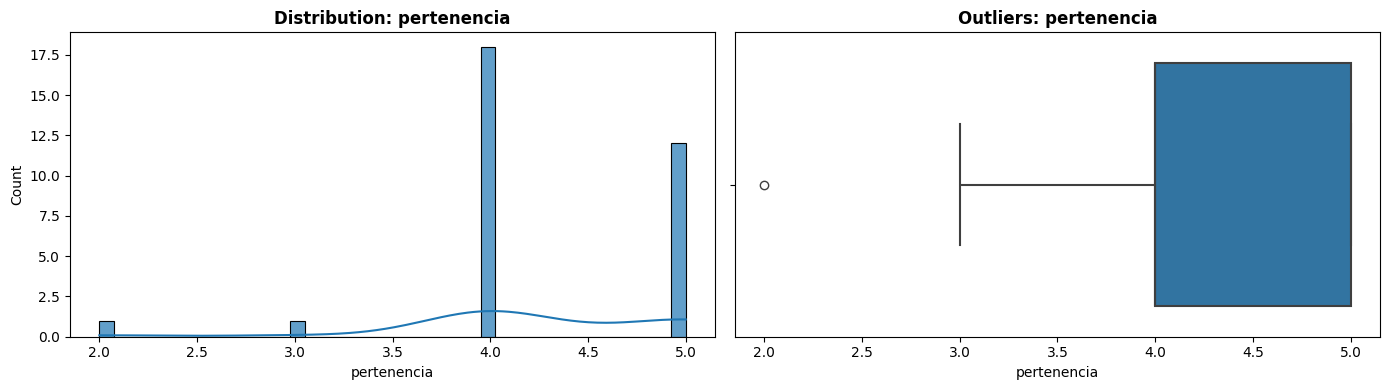

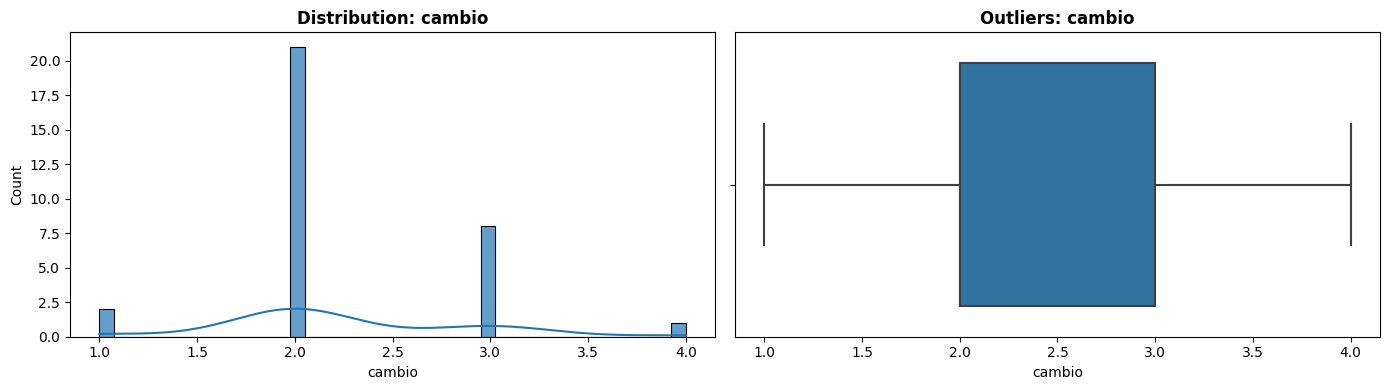

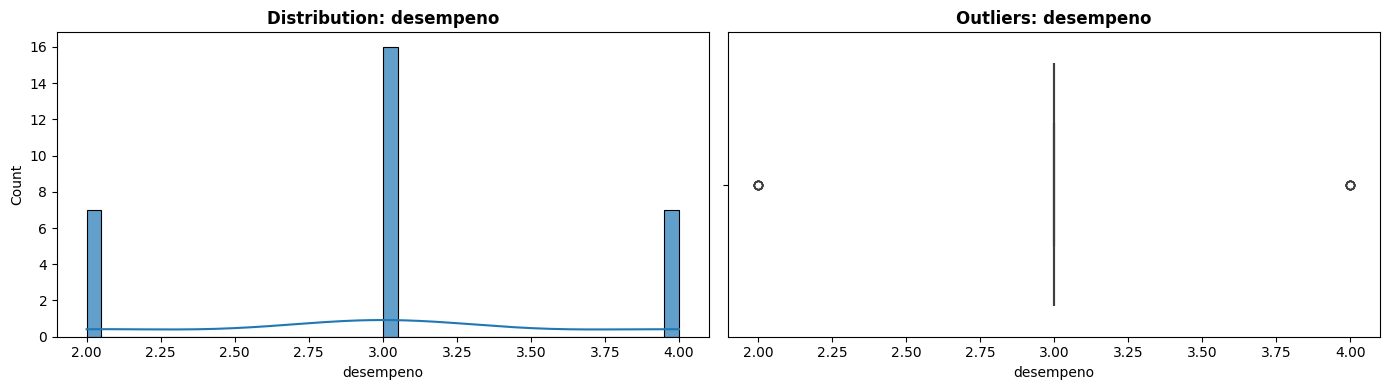

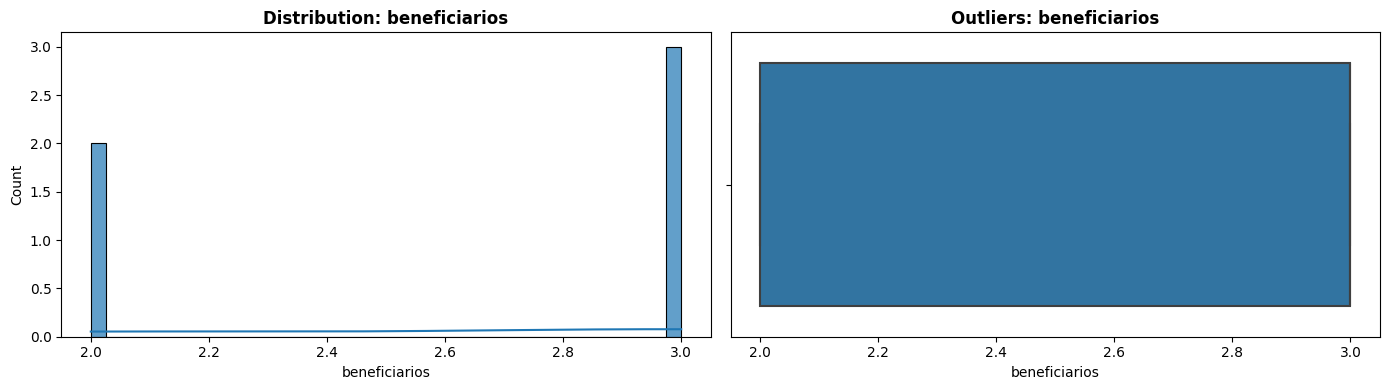

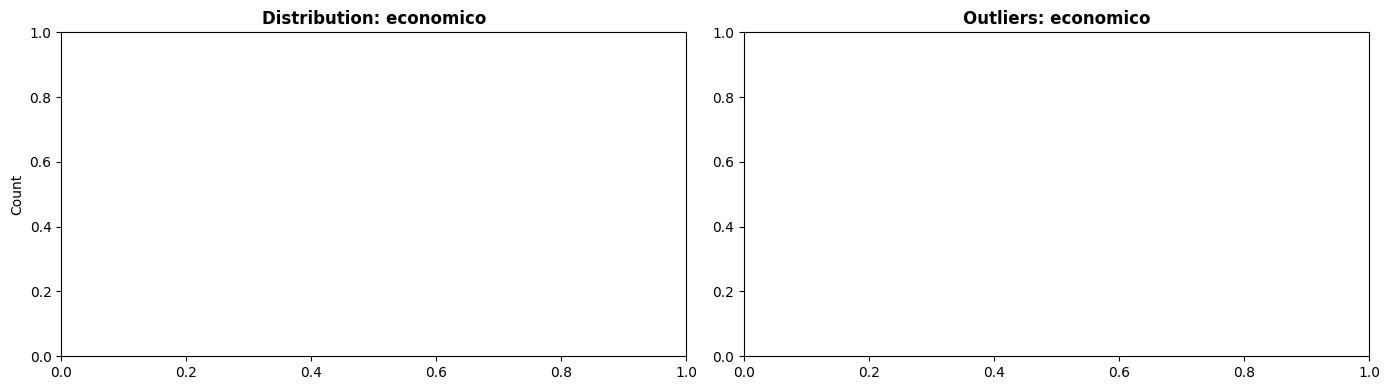

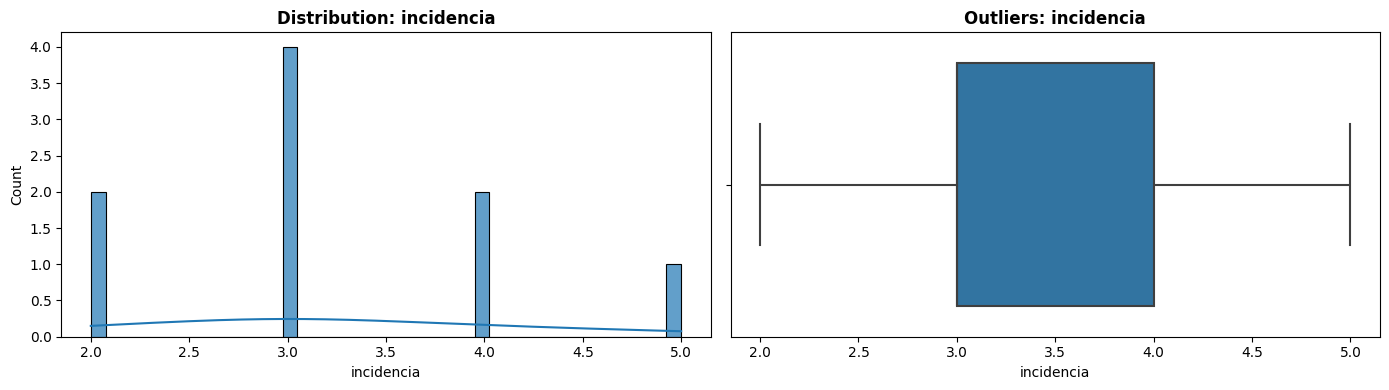

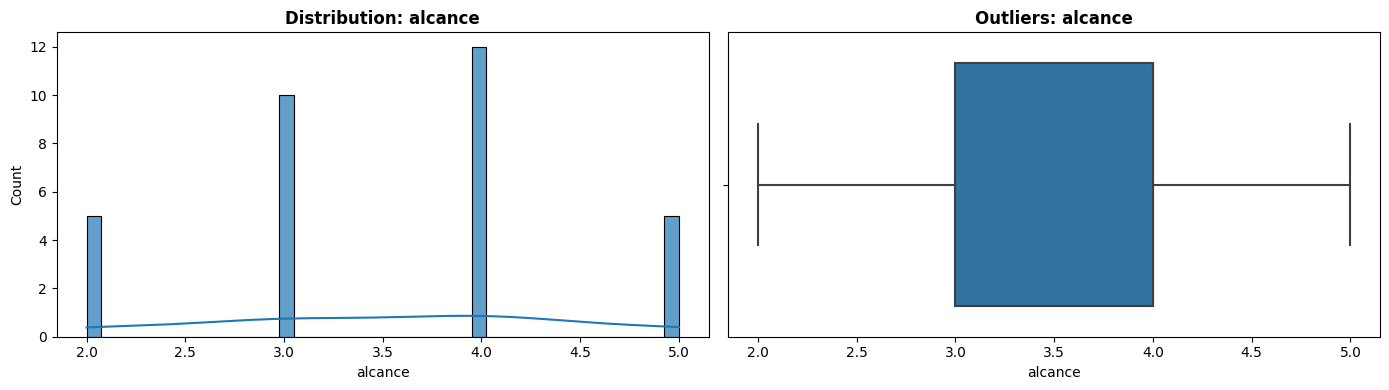

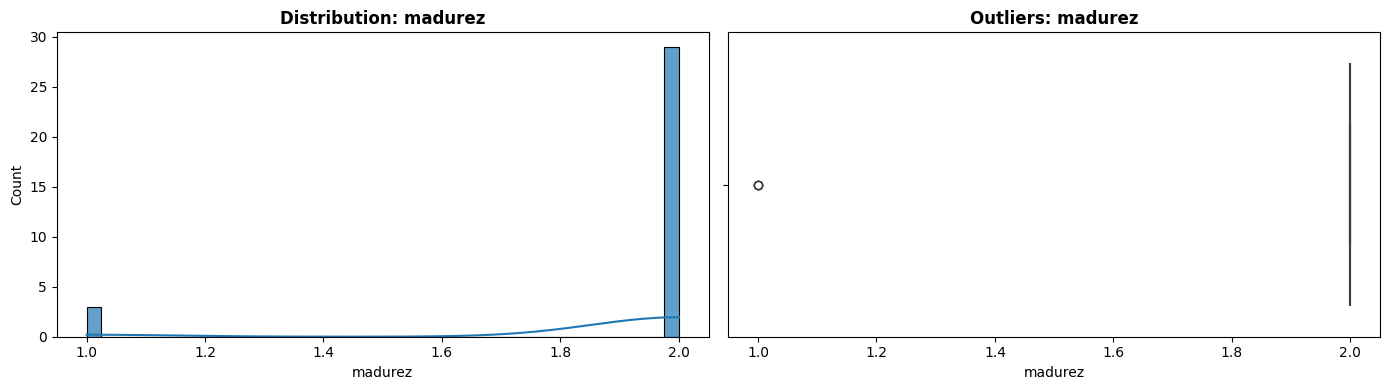

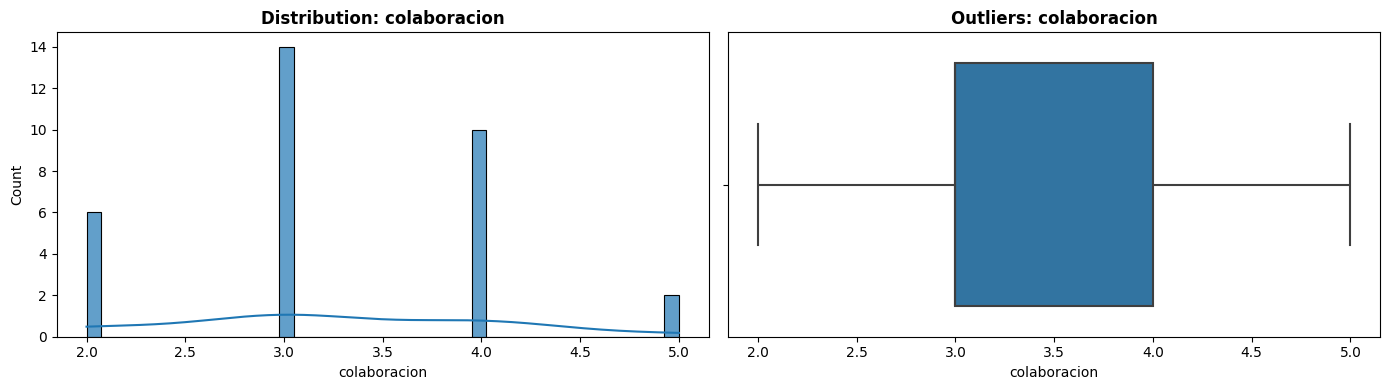

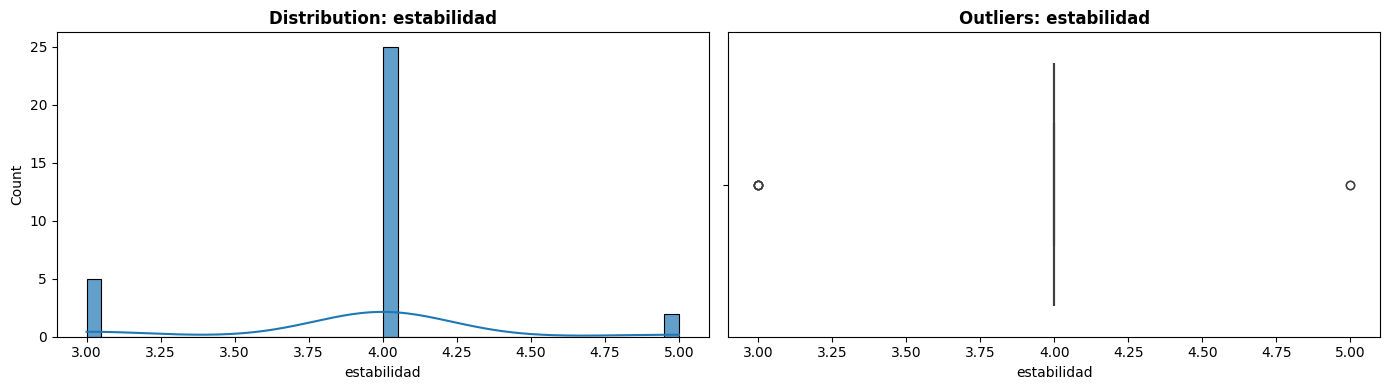

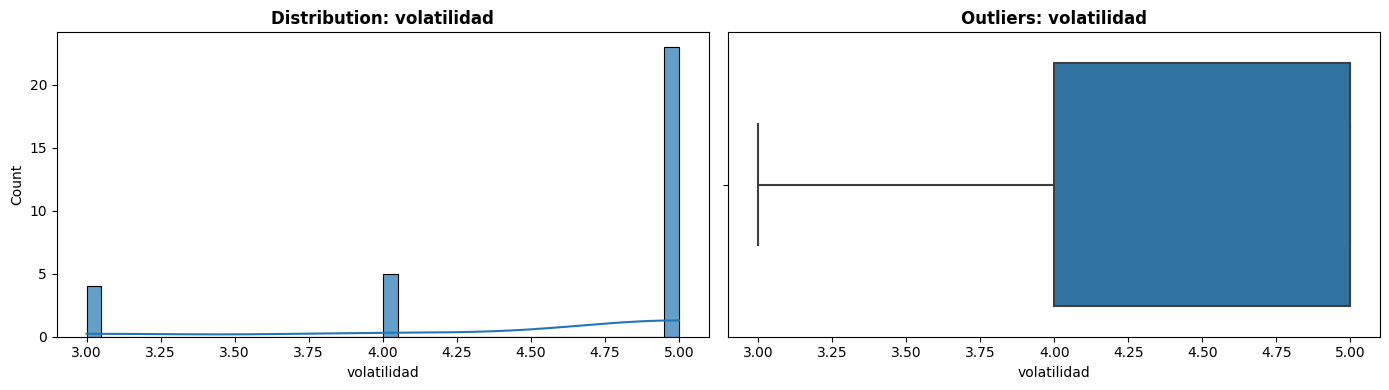

In [5]:
#Define columns
proyectos_cols = ['calidad', 'sostenibilidad', 'uso', 'satisfaccion', 'pertenencia', 'cambio', 
                  'desempeno', 'beneficiarios', 'economico', 'incidencia', 'alcance', 'madurez',
                  'colaboracion', 'estabilidad', 'volatilidad']

from visualization.explore_continuous import plot_numeric_distribution
plot_numeric_distribution(df_proyectos, proyectos_cols)

The distributions show generally mid-to-high scores across most evaluated project dimensions, with clear concentration around values 3–4 for variables such as *quality*, *collaboration*, *stability*, and *volatility*. Several variables exhibit strong skewness (e.g., *volatility* concentrated at 5, *satisfaction* at 4, and *pertinence* at 4–5), while others are more centered at mid-levels (e.g., *sustainability*, *usage*, and *change*). 

Missing values are concentrated in a few indicators (notably *beneficiaries*, *incidence*, and *economic*), which is expected given that not all projects produce the same types of results and that these indicators are only applicable to specific project typologies.

**Deliverable-Level Correlation Analysis**

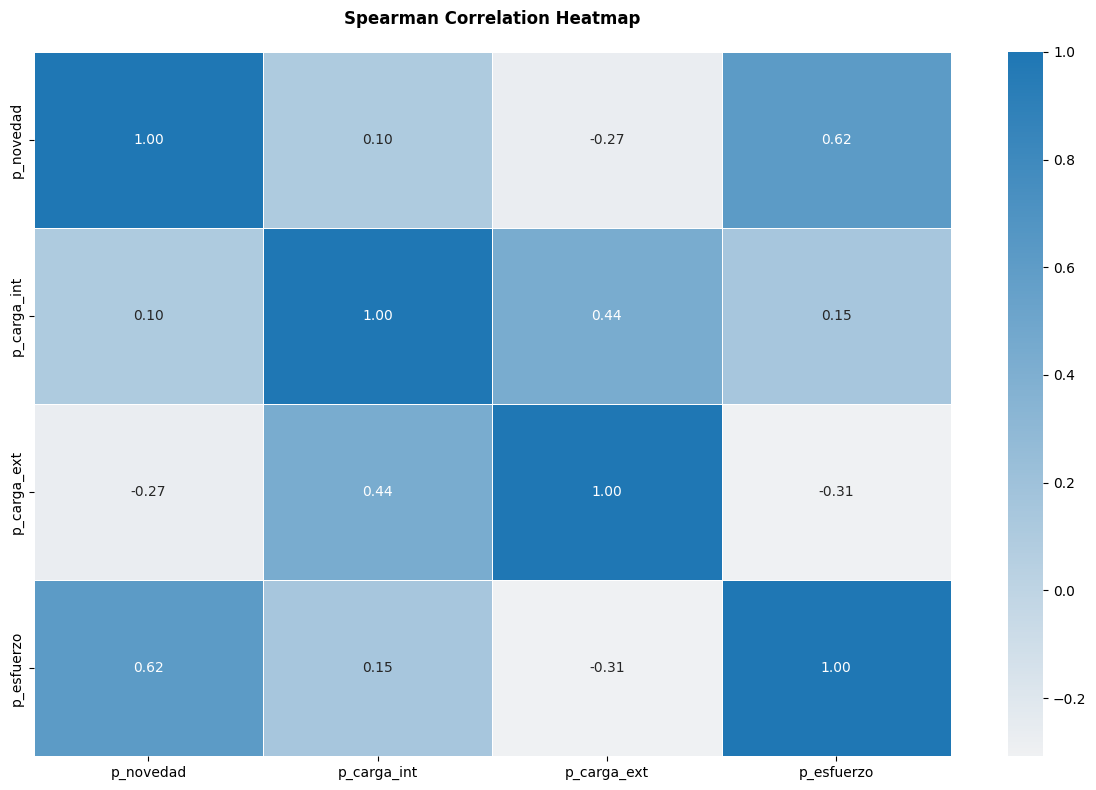

In [6]:
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(df_entregables, entregables_cols)

The correlation structure shows two moderate positive associations (*p_novedad–p_esfuerzo* and *p_carga_int–p_carga_ext*), while most other relationships remain weak or near zero, with a few mild negative associations involving *p_carga_ext*. Overall, the variables display partial but limited clustering rather than a strong unified structure.

**Project-Level Correlation Analysis**

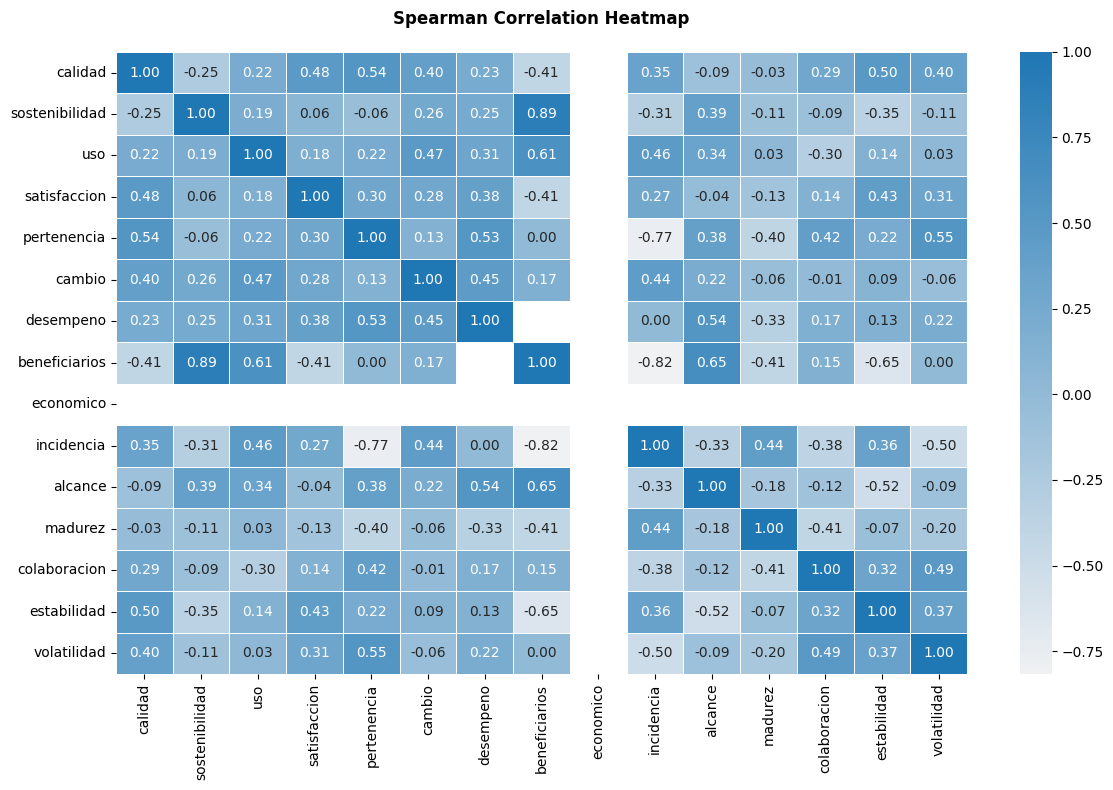

In [7]:
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(df_proyectos, proyectos_cols)

The correlation matrix shows several strong associations between project performance-related variables, particularly between *sustainability*, *beneficiaries*, *usage*, and *scope*. A strong negative relationship is observed between *incidence* and *beneficiaries*, while additional negative associations involve *incidence* and *pertinence*. Overall, the structure is moderately clustered but also shows clear opposing patterns across certain outcome-oriented dimensions rather than a single unified structure.

## 2.3-Cross-Level Consistency Check

This section summarizes the structural relationships across program levels, including projects, mandates, partners, and cooperants. The objective is to validate the operational density of the reconstructed program architecture and to quantify the distribution of deliverables across organizational layers.

| Level     | Metric                     | Min | Max | Median | Mean  | Key Insight                                                               |
| --------- | -------------------------- | --- | --- | ------ | ----- | ------------------------------------------------------------------------- |
| Project   | Deliverables per project   | 1   | 9   | 4      | 3.88  | Moderate project workload with relatively stable central tendency.        |
| Project   | Partners per project       | 1   | 4   | 1      | 1.25  | Strong concentration: most projects involve a single partner.             |
| Mandate   | Deliverables per mandate   | 1   | 38  | 7      | 11.27 | Highly uneven distribution of operational load across mandates.           |
| Mandate   | Projects per mandate       | 1   | 12  | 2      | 3.45  | Mandates aggregate multiple projects, acting as coordination layers.      |
| Partner   | Deliverables per partner   | 6   | 48  | 17     | 24.80 | Strong concentration of delivery volume among a small number of partners. |
| Partner   | Projects per partner       | 1   | 14  | 8      | 8.00  | Partners function as structural hubs across multiple projects.            |
| Cooperant | Deliverables per cooperant | 1   | 38  | 7.5    | 12.40 | Moderate-to-high individual workload with significant dispersion.         |
| Cooperant | Projects per cooperant     | 1   | 12  | 2.5    | 3.80  | Limited cross-project mobility, but non-negligible involvement.           |


## 2.4-Composite Indicator Construction Logic and Validation

The composite indicators were intentionally designed to capture distinct but complementary dimensions of project implementation and organizational change. Given the exploratory and reconstruction-based nature of the dataset, the objective was not to maximize statistical optimization, but to preserve interpretability and analytical usefulness across heterogeneous interventions.

| Level       | Composite Index      | Core Analytical Dimension              | Construction Logic                                                        | Analytical Objective                                                                                       |
| ----------- | -------------------- | -------------------------------------- | ------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| Deliverable | Complexity Index     | Operational intensity                  | Combines effort, workload, production volume, and methodological novelty  | Captures the level of coordination, resources, and operational complexity required to produce deliverables |
| Project     | Quality Index        | Technical rigor                        | Direct evaluation of technical quality                                    | Isolates the intrinsic quality of the project deliverables independently from usage or outcomes            |
| Project     | Adoption Index       | Organizational appropriation           | Combines relevance, satisfaction, sustainability, and usage               | Measures partner acceptance, strategic alignment, and long-term integration potential                      |
| Project     | Transformation Index | Organizational change                  | Combines internal change and organizational scope                         | Captures structural transformation and institutional diffusion within the organization                     |
| Project     | Outcomes Index       | Observable project effects             | Aggregates performance, beneficiaries, economic, and influence dimensions | Measures multidimensional effects generated by the intervention                                            |
| Project     | Context Index        | Organizational absorption capacity     | Combines maturity and collaboration conditions                            | Represents structural and relational conditions affecting implementation effectiveness                     |
| Project     | Risk Index           | Operational and contextual uncertainty | Combines internal stability and contextual volatility                     | Captures exposure to implementation instability and external uncertainty                                   |


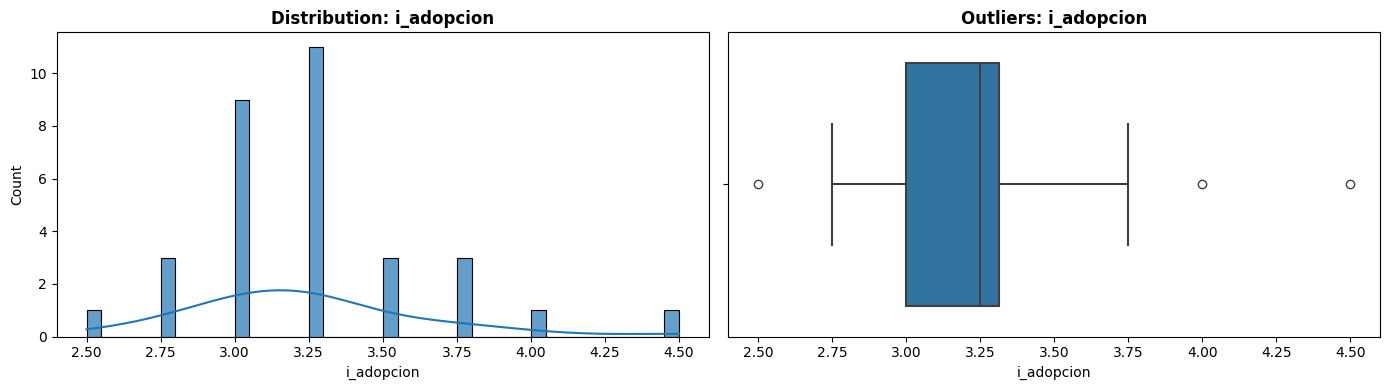

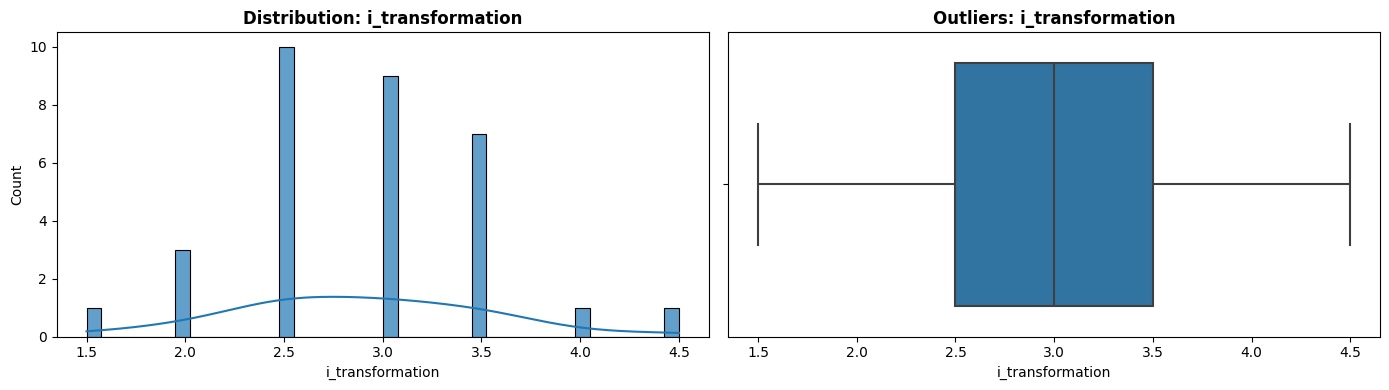

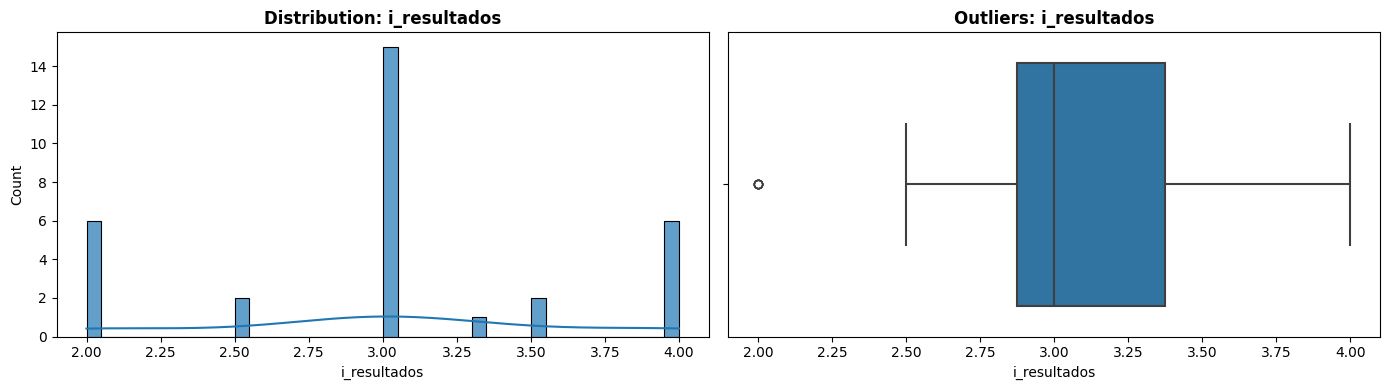

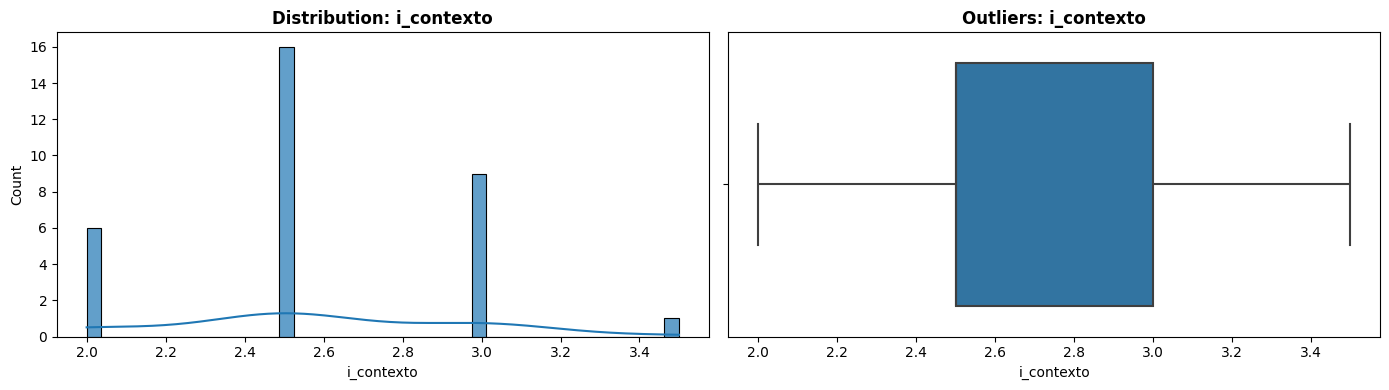

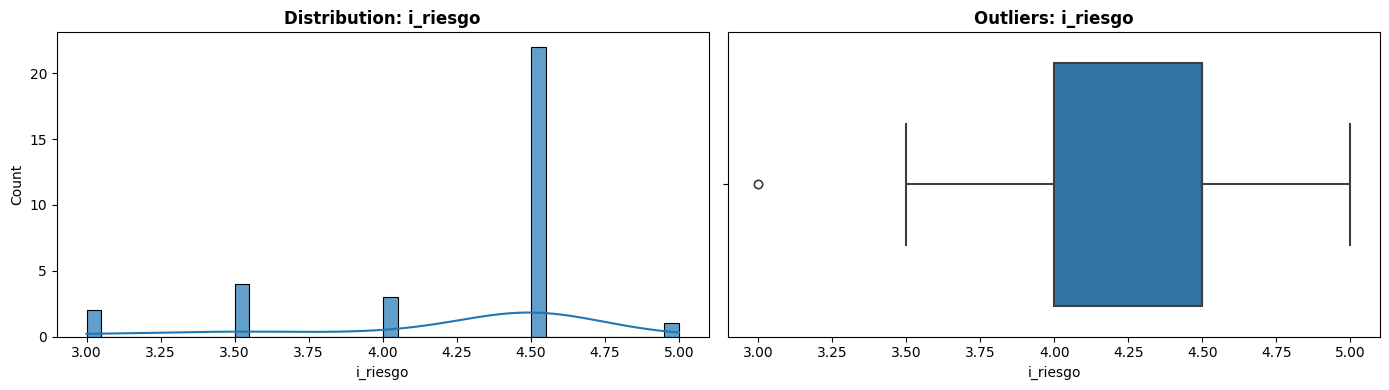

In [8]:
#Define colums
composite_cols = [
    'i_adopcion',
    'i_transformation',
    'i_resultados',
    'i_contexto',
    'i_riesgo'
]

plot_numeric_distribution(df_proyectos, composite_cols)

The composite indicators exhibit moderate levels of variability across projects, suggesting some capacity to differentiate implementation conditions and organizational dynamics within the reconstructed dataset. Adoption and contextual indices show comparatively lower dispersion (CV = 0.12–0.15), indicating more homogeneous scoring patterns across projects, while transformation and outcomes-related indices display somewhat greater variability (CV = 0.22).

Most indicators are centered around intermediate values, with median scores remaining relatively close to their respective means, suggesting broadly stable distributions without strong concentration at extreme values. The risk index tends to remain high across projects, which may reflect relatively stable implementation environments, although this interpretation should be considered cautiously given the proxy-based nature of the scoring system.

Overall, the distributions suggest that the composite indicators provide analytically usable variation while remaining sufficiently interpretable for exploratory comparative analysis. Given the reconstructed and heuristic nature of the indices, the objective is not to establish statistically validated constructs, but rather to support structured interpretation of multidimensional implementation patterns across projects.

**Indice Correlation Analysis**

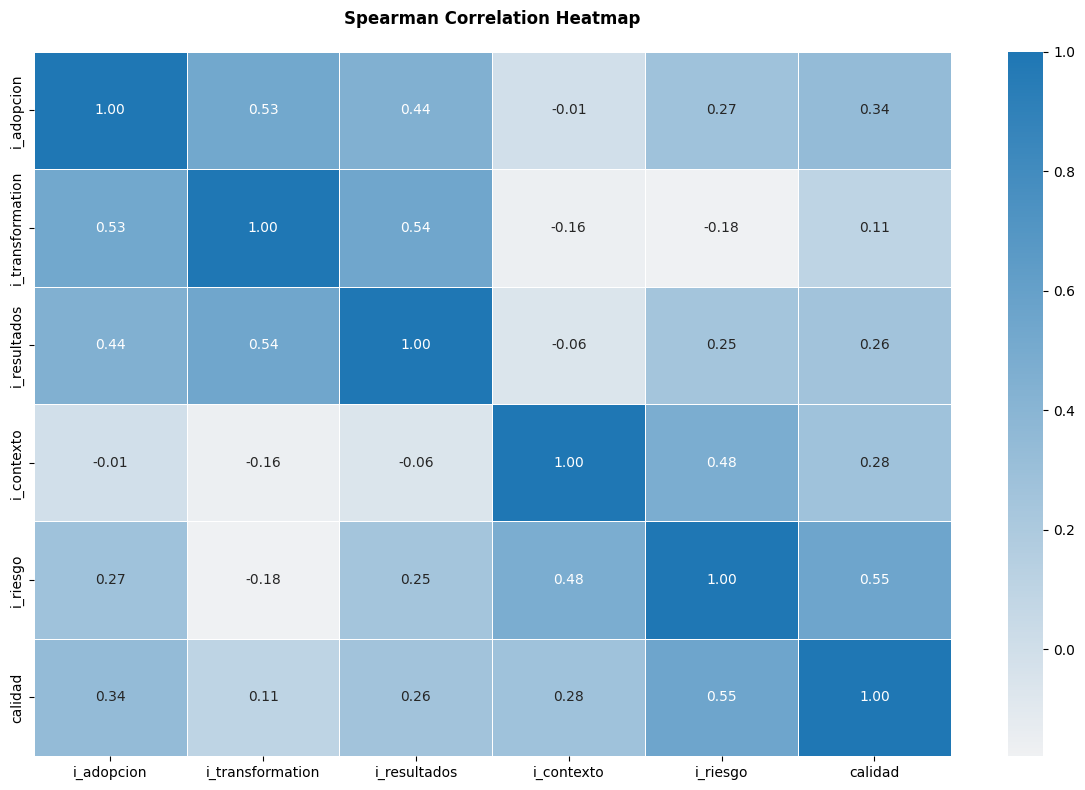

In [9]:
from visualization.explore_continuous import plot_correlation_heatmap
plot_correlation_heatmap(df_proyectos, composite_cols + ['calidad'])

The indices show a generally coherent but clearly multidimensional structure. *Adoption*, *Transformation*, and *Results* are strongly correlated (≈0.51–0.64), suggesting a shared underlying dynamic related to organizational uptake and project effects. In contrast, *Context* is weakly or negatively related to these dimensions, indicating a distinct structural role linked to absorption conditions rather than direct outputs.

*Risk* appears as a partially independent dimension, while still showing a moderate relationship with *Context* (0.49), suggesting that environmental instability is closely linked to enabling or constraining conditions. Its association with *Quality* (0.52) should be interpreted cautiously, as *Quality* in this framework reflects the intrinsic structural and technical adequacy of deliverables rather than outcome performance, and may therefore be indirectly associated with implementation conditions through project complexity or execution constraints rather than through a direct causal effect.

## 2.5-Analytical Dataset Preparation

This section builds the final analytical dataset at the project level, using df_proyectos as the base table while preserving all existing project-level variables (performance, complexity, composite indices, and classifications).

The dataset is then enriched with structural information from other program levels, including capacity (familia_capacidades) and component (titulo_componente).

Operational intensity is captured through the number of deliverables per project. The result is a single project-centric dataset that integrates structural and operational dimensions without changing the unit of analysis.

In [10]:
# Base dataset
df_final = df_proyectos.copy()

# Standardize column names
df_capacidades.columns = df_capacidades.columns.str.lower()
df_componentes.columns = df_componentes.columns.str.lower()
df_entregables.columns = df_entregables.columns.str.lower()

# Fix key name inconsistency
df_componentes = df_componentes.rename(columns={
    "id_capacidad": "id_capacitad"
})

# Number of deliverables per project
entregables_agg = df_entregables.groupby("id_proyecto").agg(
    nb_entregables=("id_entregable", "count")
).reset_index()

df_final = df_final.merge(entregables_agg, on="id_proyecto", how="left")
df_final["nb_entregables"] = df_final["nb_entregables"].fillna(0)

# Component and capacity
df_final = df_final.merge(
    df_componentes[["id_componente", "id_capacitad", "titulo_componente"]],
    on="id_componente",
    how="left"
)

df_final = df_final.merge(
    df_capacidades[["id_capacitad", "familia_capacidades"]],
    on="id_capacitad",
    how="left"
)

df_final.head()

,id_proyecto,id_componente,titulo_proyecto,ent_desempeno,ent_beneficiarios,ent_economico,ent_incidencia,tipo_proyecto,complejidad_promedio,complejidad_total,...,volatilidad,i_adopcion,i_transformation,i_resultados,i_contexto,i_riesgo,nb_entregables,id_capacitad,titulo_componente,familia_capacidades
0,1,3,Política de género (TPS),NaN,x,NaN,NaN,"Plan, estrategía o política",2.68,16.1,...,5,3.75,3.5,3.0,2.5,4.5,6,1,Política y protocolos integrales de género (sa...,Derecho de las mujeres e igualdad entre las mu...
1,2,3,Política de género (AGIMS),NaN,x,NaN,NaN,"Plan, estrategía o política",2.73,16.4,...,5,4.00,3.5,3.0,3.5,4.5,6,1,Política y protocolos integrales de género (sa...,Derecho de las mujeres e igualdad entre las mu...
2,3,5,Herramientas de seguridad y salvaguardia,x,NaN,NaN,NaN,Herramientas,2.53,10.1,...,5,2.75,2.5,2.0,2.0,4.0,4,1,Caja de herramientas - género,Derecho de las mujeres e igualdad entre las mu...
3,4,6,Capacitación sobre la política de género,NaN,x,NaN,NaN,Capacitación y transferencia de conocimientos,2.10,2.1,...,5,3.25,3.0,4.0,3.0,4.5,1,1,Fortalecimiento de conocimientos y competencia...,Derecho de las mujeres e igualdad entre las mu...
4,5,6,Capacitación - mujeres y seguridad alimentaria,NaN,NaN,NaN,x,Capacitación y transferencia de conocimientos,3.30,3.3,...,3,3.00,2.5,3.0,2.5,3.5,1,1,Fortalecimiento de conocimientos y competencia...,Derecho de las mujeres e igualdad entre las mu...


## 2.6-Feature Engineering

Given the existing set of composite and proxy indicators already integrated into the dataset, which sufficiently capture the main dimensions of performance, adoption, transformation, context, and risk, we will limit additional feature engineering to a single operational measure.

Only the production density is added as a complementary structural indicator to capture delivery intensity relative to project duration.

In [11]:
# Production density (operational intensity)
df_final["production_density"] = df_final["nb_entregables"] / df_final["duración estimada en meses"]

## 2.7-Final Dataset Cleaning and Validation

**Checking missing values**

In [12]:
df_final.isna().mean().sort_values(ascending=False)

ent_economico                 1.00000
economico                     1.00000
beneficiarios                 0.84375
ent_incidencia                0.84375
ent_beneficiarios             0.71875
incidencia                    0.71875
ent_desempeno                 0.43750
desempeno                     0.06250
id_proyecto                   0.00000
id_componente                 0.00000
titulo_proyecto               0.00000
tipo_proyecto                 0.00000
complejidad_total             0.00000
calidad                       0.00000
duración estimada en meses    0.00000
clasificación                 0.00000
sostenibilidad                0.00000
pertenencia                   0.00000
satisfaccion                  0.00000
uso                           0.00000
complejidad_promedio          0.00000
cambio                        0.00000
alcance                       0.00000
madurez                       0.00000
colaboracion                  0.00000
estabilidad                   0.00000
volatilidad 

**Creating Project Type Classification**

The original outcome-related indicators (*ent_desempeno*, *ent_beneficiarios*, *ent_economico*, *ent_incidencia*) are used to define a classification of project types.

Each project is assigned to a clear category based on its primary intervention logic:

- Internal service improvement (desempeno)
- External service improvement (beneficiarios)
- Internal impact-oriented projects (economico)
- External impact-oriented projects (incidencia)

These categories represent a structural typology of project interventions rather than mutually exclusive outcome dimensions.

In [13]:
import numpy as np

# Project type classification with priority logic
conditions = [
    df_final["ent_incidencia"].notna(),  
    df_final["ent_beneficiarios"].notna(),
    df_final["ent_desempeno"].notna()
]

choices = [
    "Proyecto de incidencia (impacto externo)",
    "Proyecto de beneficiarios (servicios externos)",
    "Proyecto de desempeño (servicios internos)"
]

df_final["project_type"] = np.select(conditions, choices, default="undefined")

# Drop redundant 'ent' indicators after classification
df_final = df_final.drop(columns=[
    "ent_desempeno",
    "ent_beneficiarios",
    "ent_economico",
    "ent_incidencia"
])

# Distribution of project types
df_final["project_type"].value_counts()

project_type
Proyecto de desempeño (servicios internos)        18
Proyecto de beneficiarios (servicios externos)     9
Proyecto de incidencia (impacto externo)           5
Name: count, dtype: int64

**Handling Missing Values**

Since these variables represent outcome-related indicators that are only applicable to specific project types, missing values do not reflect data quality issues but rather structural non-applicability. In this context, missing values are replaced with zero to ensure analytical consistency across all projects.

In [14]:
# Replace missing outcome-related indicators with 0 (non-applicable cases)
outcome_cols = [
    "desempeno",
    "beneficiarios",
    "economico",
    "incidencia"
]

df_final[outcome_cols] = df_final[outcome_cols].fillna(0)

# Quick check
df_final.isna().sum()

id_proyecto                   0
id_componente                 0
titulo_proyecto               0
tipo_proyecto                 0
complejidad_promedio          0
complejidad_total             0
clasificación                 0
duración estimada en meses    0
calidad                       0
sostenibilidad                0
uso                           0
satisfaccion                  0
pertenencia                   0
cambio                        0
desempeno                     0
beneficiarios                 0
economico                     0
incidencia                    0
alcance                       0
madurez                       0
colaboracion                  0
estabilidad                   0
volatilidad                   0
i_adopcion                    0
i_transformation              0
i_resultados                  0
i_contexto                    0
i_riesgo                      0
nb_entregables                0
id_capacitad                  0
titulo_componente             0
familia_

This dataset is now structurally complete and analytically consistent. However, it remains a reconstructed representation of program operations, designed for exploratory and comparative analysis rather than causal inference.

## 2.8-Summary - Notebook 2

| Section                            | Process                             | Key Output                                                                                              | Methodological Action                                                   | Analytical Purpose                                           |
| ---------------------------------- | ----------------------------------- | ------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------ |
| Data Loading                       | Multi-table ingestion               | 7 relational datasets (proyectos, entregables, componentes, capacidades, socios, cooperantes, mandatos) | Structured loading + repository integration                             | Establish full program data architecture                     |
| Data Quality Profiling             | Structural diagnostics              | Missingness & duplication report                                                                        | Row/column-level completeness assessment                                | Identify data quality and structural gaps                    |
| Data Model Validation              | Referential integrity check         | Orphan rate = 0 across all relations                                                                    | Cross-table key validation (projects, deliverables, mandates, partners) | Validate coherence of reconstructed program structure        |
| Proxy Indicator EDA (Deliverables) | Distribution + correlation analysis | Operational intensity patterns (p_* variables)                                                          | Descriptive statistics + correlation heatmaps                           | Assess variability of operational complexity signals         |
| Proxy Indicator EDA (Projects)     | Distribution + correlation analysis | Performance and outcome structure                                                                       | Multi-dimensional score exploration                                     | Validate discriminative capacity of project-level indicators |
| Cross-Level Consistency Check      | Structural aggregation              | Workload distribution across projects, mandates, partners, cooperants                                   | Multi-level aggregation (min/max/mean/median)                           | Assess operational density and organizational hierarchy      |
| Composite Indicator Review         | Index validation                    | Multiple composite indices                                  | Distribution + variability analysis                                     | Validate multidimensional synthetic constructs               |
| Dataset Construction               | Feature integration                 | Unified project-level dataset (df_final)                                                                | Left joins across components, capacities, deliverables                  | Build analytical dataset                            |
| Feature Engineering                | Operational enrichment              | production_density                                                                                      | Derived ratio (deliverables / duration)                                 | Capture operational intensity over time                      |
| Project Typology Construction      | Structural classification           | project_type variable                                                                                   | Rule-based classification from outcome indicators                       | Define intervention logic taxonomy                           |
| Missing Data Handling              | Structural imputation               | Outcome variables cleaned (0 replacement)                                                               | Contextual imputation based on non-applicability                        | Ensure analytical consistency across typologies              |
| Final Dataset Validation           | Integrity check                     | Fully non-missing analytical dataset                                                                    | Final NA audit + schema verification                                    | Confirm structural completeness             |


## 2.9-Data Export

In [15]:
# Export final dataset (ML-ready)
df_final.to_csv("pcv_guatemala_project_dataset.csv", index=False)